<a href="https://colab.research.google.com/github/WinstonNji/Recurrent-Neural-Network-Practice/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM From Scratch

In [ ]:
import numpy as np

np.random.seed(42)

t = np.linspace(0, 4 * np.pi, 23)
raw = np.sin(t)

seq_len    = 3
input_size = 1
hidden_size = 2
output_size = 1

X, y = [], []
for i in range(len(raw) - seq_len):
    X.append(raw[i : i + seq_len])
    y.append(raw[i + seq_len])

X = np.array(X).reshape(-1, seq_len, input_size)
y = np.array(y).reshape(-1, output_size)

print("X:", X.shape)   # (20, 3, 1)
print("y:", y.shape)   # (20, 1)

X: (20, 3, 1)
y: (20, 1)


In [ ]:
def sigmoid(z):
  return 1  / (1 + np.exp(-z))

def sigmoid_derivative(gate):
  return gate * (1 - gate)

In [ ]:
d = input_size + hidden_size

Wf = np.random.randn(hidden_size,d)
Wi = np.random.randn(hidden_size,d)
Wo = np.random.randn(hidden_size,d)
Wg = np.random.randn(hidden_size,d)
Wy = np.random.randn(output_size,hidden_size)

bf = np.zeros((hidden_size,1))
bi = np.zeros((hidden_size,1))
bo = np.zeros((hidden_size,1))
bg = np.zeros((hidden_size,1))
by = np.zeros((output_size,1))

loss_tracker = []
epochs = 500
lr = 0.01

In [ ]:
for epoch in range(epochs):
  loss_per_epoch = 0

  for s in range(len(X)):
    h = np.zeros((hidden_size,1))
    c = np.zeros((hidden_size,1))

    cache = []

    for t in range(seq_len):
      #  ########### FORWARD PASSS ################
      x_t = X[s,t].reshape(input_size,1)
      z = np.vstack([x_t,h])

      f_gate = sigmoid(Wf @ z + bf)
      i_gate = sigmoid(Wi @ z + bi)
      o_gate = sigmoid(Wo @ z + bo)
      g_gate = np.tanh(Wg @ z + bg)

      c_new = f_gate * c + i_gate * g_gate
      h_new = o_gate * np.tanh(c_new)

      cache.append( ( c, h , x_t , z , f_gate , i_gate , o_gate , g_gate , c_new ,h_new ) )

      h = h_new
      c = c_new

    # ############### LOSS COMPUTATION #############

    y_pred = Wy @ h + by
    y_target = y[s].reshape(output_size,1)

    loss = 0.5 * (y_pred - y_target) ** 2
    loss_per_epoch += loss.item()

    # ################# BACKPROPAGATION THROUGH TIME ###################

    # ---  Weigt and Bias gradient reintinialisation --

    dWf = np.zeros_like(Wf)
    dWi = np.zeros_like(Wi)
    dWo = np.zeros_like(Wo)
    dWg = np.zeros_like(Wg)

    dbf = np.zeros_like(bf)
    dbi = np.zeros_like(bi)
    dbo = np.zeros_like(bo)
    dbg = np.zeros_like(bg)

    d_c_next = np.zeros((hidden_size,1))

    # -------- OUTPUT ---------

    dy = y_pred - y_target
    dWy = dy @ h.T
    dby = dy

    # --- Hidden State Delta / Gradient ---

    dh = Wy.T @ dy

    # Gradient of

    for t in reversed(range(seq_len)):
      c, h , x_t , z , f_gate , i_gate , o_gate , g_gate , c_new ,h_new = cache[t]

      #  c_t gradient
      dc = dh * o_gate * (1 - np.tanh(c_new) ** 2) + d_c_next * f_gate

      # Gradients for gates

      df_gate = dc * c * sigmoid_derivative(f_gate)
      di_gate = dc * g_gate * sigmoid_derivative(i_gate)
      dg_gate = dc * i_gate * (1 - g_gate ** 2)
      do_gate = dh * np.tanh(c_new) * sigmoid_derivative(o_gate)

      # Gradient Weights for gates

      dWf += df_gate @ z.T
      dWi += di_gate @ z.T
      dWo += do_gate @ z.T
      dWg += dg_gate @ z.T

      dbf += df_gate
      dbi += di_gate
      dbo += do_gate
      dbg += dg_gate


      d_c_next = dc * f_gate

      dz = Wf.T @ df_gate + Wi.T @ di_gate + Wg.T @ dg_gate + Wo.T @ do_gate

      dh = dz[input_size:]

    for param, grad in [
            (Wf, dWf), (Wi, dWi), (Wg, dWg), (Wo, dWo),
            (bf, dbf), (bi, dbi), (bg, dbg), (bo, dbo),
            (Wy, dWy), (by, dby)
        ]:
            param -= lr * grad

  loss_tracker.append(loss_per_epoch)
  if epoch % 50 == 0:
      print(f"epoch {epoch}  loss {loss_per_epoch / len(X):.4f}")


epoch 0  loss 0.2011
epoch 50  loss 0.1134
epoch 100  loss 0.0798
epoch 150  loss 0.0558
epoch 200  loss 0.0390
epoch 250  loss 0.0279
epoch 300  loss 0.0206
epoch 350  loss 0.0155
epoch 400  loss 0.0117
epoch 450  loss 0.0087


In [ ]:
pred = []
actual = []

for s in range(len(X)):
    h = np.zeros((hidden_size,1))
    c = np.zeros((hidden_size,1))

    cache = []

    for t in range(seq_len):
      #  ########### FORWARD PASSS ################
      x_t = X[s,t].reshape(input_size,1)
      z = np.vstack([x_t,h])

      f_gate = sigmoid(Wf @ z + bf)
      i_gate = sigmoid(Wi @ z + bi)
      o_gate = sigmoid(Wo @ z + bo)
      g_gate = np.tanh(Wg @ z + bg)

      c_new = f_gate * c + i_gate * g_gate
      h_new = o_gate * np.tanh(c_new)

      cache.append( ( c, h , x_t , z , f_gate , i_gate , o_gate , g_gate , c_new ,h_new ) )

      h = h_new
      c = c_new

    # ############### LOSS COMPUTATION #############

    y_pred = Wy @ h + by
    pred.append(y_pred.item())

    y_target = y[s].reshape(output_size,1)
    actual.append(y_target.item())

    loss = 0.5 * (y_pred - y_target) ** 2
    loss_per_epoch += loss.item()

In [ ]:
import matplotlib.pyplot as plt

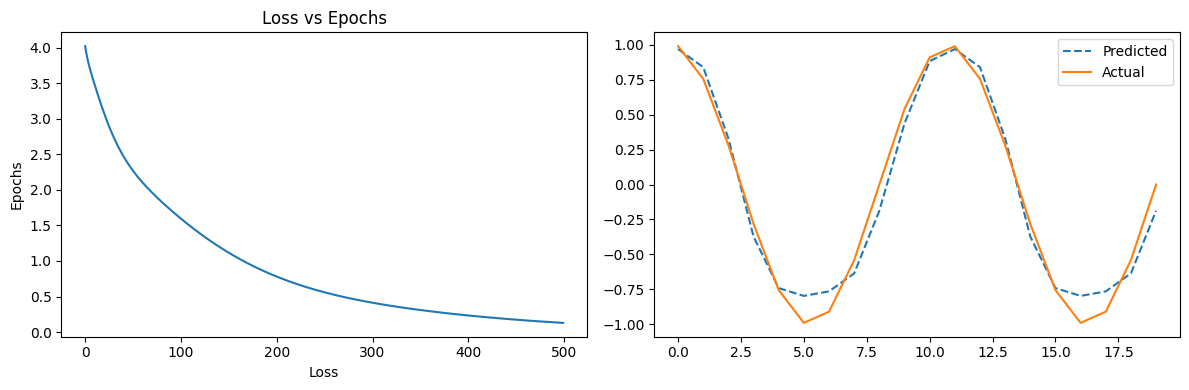

In [ ]:
fig, axes = plt.subplots(1,2, figsize = (12,4))

axes[0].plot(loss_tracker)
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Loss')
axes[0].set_ylabel('Epochs')

axes[1].plot(pred, label='Predicted', linestyle='--')
axes[1].plot(actual, label='Actual')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
mae = mean_absolute_error(actual,pred)
print(mae)

0.0943916867951832


## Comparison to RNN on same data

In [ ]:
Wxh = np.random.randn(hidden_size,input_size) * 0.01
Whh = np.random.randn(hidden_size,hidden_size) * 0.01
Why = np.random.randn(output_size,hidden_size) * 0.01

bh = np.zeros((hidden_size,1))
by = np.zeros((output_size,1))

In [ ]:
for epoch in range(epochs):
  loss_per_epoch = 0

  for s in range(len(X)):
    h = np.zeros((hidden_size,1))
    hs = {0:h.copy()}

    for t in range(seq_len):

      # ######### FORWARD PASS #############33

      x_t = X[s,t].reshape(input_size,1)

      h = np.tanh(Wxh @ x_t + Whh @ h + bh)
      hs[t + 1] = h.copy()

    y_pred = Why @ h + by
    y_target = y[s].reshape(output_size,1)

    loss = 0.5 * (y_pred - y_target) ** 2
    loss_per_epoch += loss.item()



    # ############ BACKPROPAGATION ############

    dWxh = np.zeros_like(Wxh)
    dWhh =  np.zeros_like(Whh)
    dWhy =  np.zeros_like(Why)
    dby = np.zeros_like(by)
    dbh = np.zeros_like(bh)

    dh_next = np.zeros((hidden_size,1))

    dy = y_pred - y_target
    dWhy += dy @ h.T
    dby += dy

    for t in reversed(range(1,seq_len+1)):
      x_t = X[s,t-1].reshape(input_size,1)

      dh  = (Why.T @ dy + dh_next) * (1 - hs[t] ** 2)

      dWhh += dh @ hs[t-1].T
      dWxh += dh @ x_t.T

      dbh += dh

      dh_next = Whh.T @ dh

    for grad in [dWxh, dWhh, dWhy, dbh, dby]:
      np.clip(grad, -1, 1, out=grad)

    Wxh -= lr * dWxh
    Whh -= lr * dWhh
    Why -= lr * dWhy
    bh -= lr * dbh
    by -= lr * dby

  loss_tracker.append( loss_per_epoch / len(X))

  if epoch % 10 == 0:
    print(f"Epoch: {epoch}, Loss: {loss_per_epoch}")

Epoch: 0, Loss: 4.9769693806513295
Epoch: 10, Loss: 4.929339360576086
Epoch: 20, Loss: 4.907376396410429
Epoch: 30, Loss: 4.726638224283049
Epoch: 40, Loss: 3.770705283833174
Epoch: 50, Loss: 2.290826225336545
Epoch: 60, Loss: 1.6667844598793697
Epoch: 70, Loss: 1.4426212504665308
Epoch: 80, Loss: 1.3933041144346063
Epoch: 90, Loss: 1.4509954944704067
Epoch: 100, Loss: 1.555234869799309
Epoch: 110, Loss: 1.6546939171763788
Epoch: 120, Loss: 1.7259750867882495
Epoch: 130, Loss: 1.76579466791122
Epoch: 140, Loss: 1.772850485461146
Epoch: 150, Loss: 1.7305361059533373
Epoch: 160, Loss: 1.5807341865631968
Epoch: 170, Loss: 1.206214957206964
Epoch: 180, Loss: 0.6102933993017515
Epoch: 190, Loss: 0.18914604275291594
Epoch: 200, Loss: 0.07779307552172099
Epoch: 210, Loss: 0.06300940941190798
Epoch: 220, Loss: 0.061481900444021326
Epoch: 230, Loss: 0.06116722080728945
Epoch: 240, Loss: 0.06090130653991602
Epoch: 250, Loss: 0.06061295189880046
Epoch: 260, Loss: 0.06030780545938302
Epoch: 270, L

In [ ]:
pred = []
actual = []

for i in range(len(X)):
    h = np.zeros((hidden_size,1))
    hs = {0:h.copy()}

    for t in range(seq_len):
      # ---------- FORWARD PASSS ----------
      x_t = X[i,t].reshape(1,1)

      h = np.tanh(Wxh @ x_t + Whh @ h + bh)
      hs[t+1] = h.copy()

    # --------- Compute loss ------------

    y_pred = Why @ h + by
    pred.append(y_pred.item())

    y_target = y[i].reshape(1,1)
    actual.append(y_target.item())




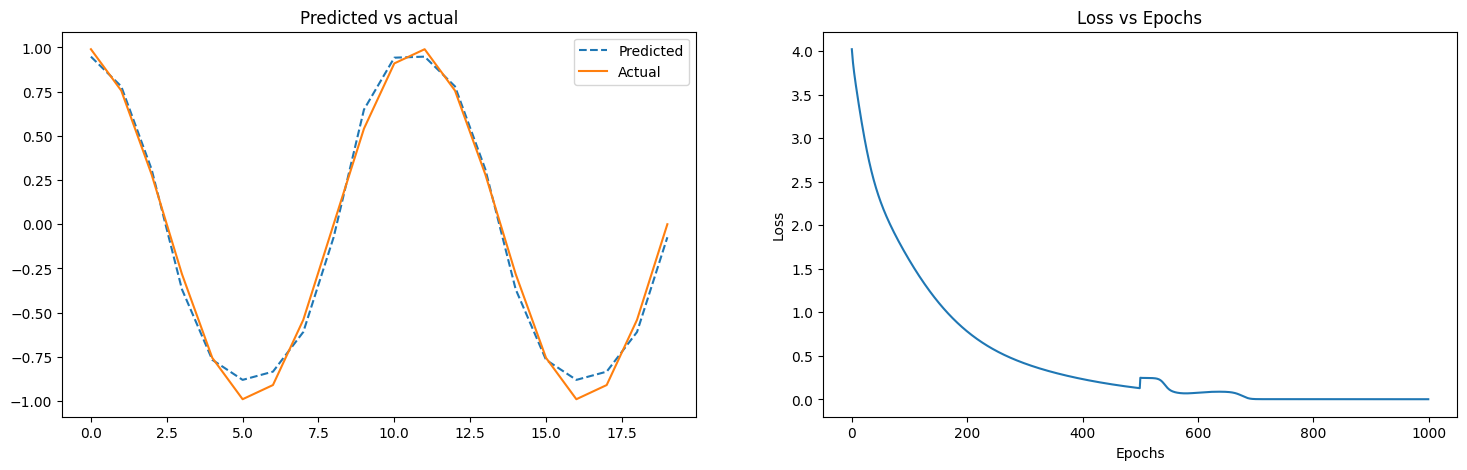

In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(18,5))

ax[0].plot(pred, label='Predicted', linestyle='--')
ax[0].plot(actual, label='Actual')
ax[0].set_title('Predicted vs actual')
ax[0].legend()

ax[1].plot(loss_tracker)
ax[1].set_title('Loss vs Epochs')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')


plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

In [ ]:
mae = mean_absolute_error(actual,pred)
print(mae)

0.05902739635006893


# LSTM TF

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
X = X.reshape(-1,seq_len,1)

In [ ]:
pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential

In [ ]:
model = Sequential([
    layers.LSTM(32, return_sequences=True, input_shape = (hidden_size,input_size)),
    layers.LSTM(16),
    layers.Dense(output_size)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)

In [ ]:
history = model.fit(
    X,
    y,
    validation_split = 0.2,
    epochs = 150,
    verbose = 1
)

Epoch 1/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.4739 - mae: 0.6202 - val_loss: 0.5016 - val_mae: 0.6018
Epoch 2/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.4717 - mae: 0.6187 - val_loss: 0.5045 - val_mae: 0.6033
Epoch 3/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.4697 - mae: 0.6172 - val_loss: 0.5074 - val_mae: 0.6047
Epoch 4/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.4677 - mae: 0.6157 - val_loss: 0.5104 - val_mae: 0.6062
Epoch 5/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.4659 - mae: 0.6141 - val_loss: 0.5133 - val_mae: 0.6076
Epoch 6/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.4641 - mae: 0.6126 - val_loss: 0.5160 - val_mae: 0.6089
Epoch 7/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.4625 - mae: 0.6110 - val_loss: 0.5185 - val_mae: 0.6101
Epoch 8/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.4609 - mae: 0.6095 - val_loss: 0.5206 - val_mae: 0.6111
Epoch 9/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.4594 - mae:

In [ ]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1000ms/step


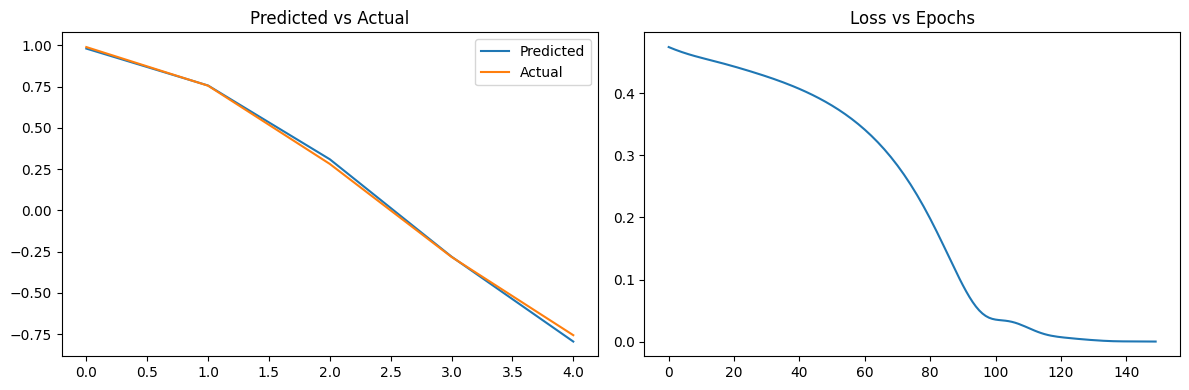

In [ ]:

fig, axes = plt.subplots(1,2, figsize = (12,4))

axes[0].plot(pred[0:5].flatten(), label='Predicted')
axes[0].plot(y[0:5], label = 'Actual')
axes[0].legend()
axes[0].set_title('Predicted vs Actual')


axes[1].plot(history.history['loss'])
axes[1].set_title('Loss vs Epochs')

plt.tight_layout()
plt.show()